# CPBL 2023+2024 即時勝率 Live Win Probability

從**賽前靜態模型**進化到**比賽進行中的情境狀態模型**：依「局數 / 上下半 / 分差 / 出局數 / 壘包」即時更新主隊勝率，並畫出球迷熟悉的**動態勝率曲線**。

**四大核心 → 對應 Stage**
- 概念1 即時狀態 → **Stage 1** 逐打席 (per-PA) 狀態表
- 概念2 兩大方法 → **Stage 3** 歷史頻率查表法 + **Stage 4** LightGBM（外加邏輯迴歸對照）
- 概念3 賽前實力修正 → **Stage 5** Elo 賽前勝率 + 貝氏權重融合 `w·賽前 + (1−w)·賽中`
- 概念4 資料流 + 視覺化 → **Stage 6** `predict_live_probability()` + 點選任一場、用該場之前資料訓練 (expanding window)、逐打席回放畫即時勝率曲線

**資料**：repo 內 rebas.tw 逐打席開放資料（2023 本地 JSON + 2024 由另一 repo `git show` 唯讀讀取），每打席含 `inning/outs/bases/score`、官方 `homeWE/WPA/RE24`（外部對照線）。

**因果性**：跨比賽用「截止日前訓練 → 之後套用」(expanding-window 精神)，場內僅用「開賽到當下」的特徵；標籤用最終勝負 `final_win`（監督式正常做法，非洩漏）。

## Stage 0 — 環境設定與全域開關

**【目標 What?】** 載入套件、固定亂數、設定資料路徑與「切分模式」總開關。
**【說明 How?】** `SPLIT_MODE` gate 讓整本可一鍵在兩種 train/holdout 切分間切換；輸出預設 inline、不寫檔（`DOWNLOAD_ALL`）。
**【解釋結果 Why?】** 單一開關集中所有下游切分，確保時序紀律一致、零改碼即可重跑另一模式。

In [1]:
import json, glob, subprocess, datetime as dt, warnings, io, zipfile
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.ticker as mticker
import seaborn as sns
try:
    import lightgbm as lgb
except ImportError:
    import sys; get_ipython().run_line_magic("pip", "install -q lightgbm"); import lightgbm as lgb
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
for f in ["Noto Sans CJK TC", "Microsoft JhengHei", "Arial Unicode MS", "DejaVu Sans"]:
    plt.rcParams["font.sans-serif"] = [f] + plt.rcParams["font.sans-serif"]
plt.rcParams["axes.unicode_minus"] = False
print("pandas", pd.__version__, "| numpy", np.__version__, "| lightgbm", lgb.__version__)

# ---- output / artifact switch (inline by default) ----
DOWNLOAD_ALL = False
ARTIFACTS = []
def show_and_track(obj, name, kind="fig"):
    """Register an artifact; save to /tmp only when DOWNLOAD_ALL. Returns obj."""
    ARTIFACTS.append((name, kind))
    if kind == "fig" and DOWNLOAD_ALL:
        obj.savefig(f"/tmp/{name}", bbox_inches="tight")
    if kind == "csv" and DOWNLOAD_ALL:
        obj.to_csv(f"/tmp/{name}", index=False)
    return obj

pandas 3.0.3 | numpy 2.4.6 | lightgbm 4.6.0


**【目標 What?】** 設定資料來源與切分總開關。
**【說明 How?】** 2023=本地四個目錄；2024=從 `data_science` repo 的 `analyze_wang` 分支 `git show` 唯讀取得（不 checkout、不需網路）。`SPLIT_MODE` 預設 `B`（訓練庫最大且最新）。
**【解釋結果 Why?】** `CUTOFF_DATE` 把 2024 切成「歷史庫 vs 未來現場」，對應使用者「只用之前比賽」的限制。

In [2]:
DIRS_2023 = sorted(glob.glob("/home/user/data_science_final_project/Data/2023/*/"))
REPO_2024 = "/home/user/data_science"
REF_2024 = "origin/analyze_wang:data/raw/CPBL-2024-OpenData/CPBL-2024-OpenData.json"

SPLIT_MODE = "B"          # "A": train 2023 / holdout 2024 全季 ;  "B": train <CUTOFF / holdout >=CUTOFF
CUTOFF_DATE = pd.Timestamp("2024-09-01")

def w_inning(inn):
    """賽前先驗權重：第1局=1（全靠賽前），第9局起=0（全靠賽中），線性衰減。"""
    return np.clip(1 - (np.asarray(inn, dtype=float) - 1) / 8, 0.0, 1.0)

print("2023 dirs:", len(DIRS_2023), "| SPLIT_MODE =", SPLIT_MODE, "| CUTOFF =", CUTOFF_DATE.date())

2023 dirs: 4 | SPLIT_MODE = B | CUTOFF = 2024-09-01


## Stage 0.5 — 共用工具箱（OO 介面：一次定義、到處重用）

**【目標 What?】** 把「帶狀態」的東西包成**共用 sklearn 介面**（`fit`→`self`、`predict_proba`→2D），其餘為小而純的函式。
**【說明 How?】** 四個模型（查表 / LR / LGBM / 融合）都吃**同一個完整 PA DataFrame**、各自挑欄位 → 評估、繪圖、回放只寫一次、對模型字典迴圈套用。
**【解釋結果 Why?】** 多型 (polymorphism) 消除重複的長 cell；新增模型不必改評估碼。

In [3]:
class EloRater(BaseEstimator):
    """賽前實力評分。逐場按時間推進、每場用「賽前 (pre-update) 評分」算主隊勝率期望 → 無洩漏。"""
    def __init__(self, base=1500.0, k=20.0, home=50.0):
        self.base, self.k, self.home = base, k, home
    def fit(self, games):                       # games: 一場一列、已按 date 排序、含 home_win
        self.ratings_, self.pregame_ = {}, {}
        for r in games.itertuples():
            rh = self.ratings_.get(r.home_team, self.base)
            ra = self.ratings_.get(r.away_team, self.base)
            eh = 1 / (1 + 10 ** (-(rh + self.home - ra) / 400))
            self.pregame_[r.game_id] = eh          # 賽前評分算出的主隊勝率
            sc = float(r.home_win)
            self.ratings_[r.home_team] = rh + self.k * (sc - eh)
            self.ratings_[r.away_team] = ra + self.k * ((1 - sc) - (1 - eh))
        return self

**【目標 What?】** 方法 A — 歷史頻率查表法（吸收型 Markov 鏈的經驗估計）。
**【說明 How?】** 階層式經驗貝氏：由粗到細 `(局,半,分差)→+出局→+壘包`，每層用虛擬計數 `M` 向上層收縮；count=0 時公式自然退回上層估計（自動 back-off）。
**【解釋結果 Why?】** 稀疏的高槓桿狀態不會因少數樣本而暴衝，且全程**向量化**（無 per-row 迴圈）。

In [4]:
class LookupWP(BaseEstimator, ClassifierMixin):
    """階層經驗貝氏查表勝率；稀疏狀態向較粗父狀態收縮。"""
    def __init__(self, score_clip=10, M=5.0):
        self.score_clip, self.M = score_clip, M
    def _keys(self, X):
        inn = np.minimum(X["inning"].values, 10).astype(int)
        sd = np.clip(X["score_diff"].values, -self.score_clip, self.score_clip).astype(int)
        hf, ot, bs = X["half_inning"].values, X["outs"].values, X["base_state"].values
        k2 = [f"{a}|{b}|{c}" for a, b, c in zip(hf, sd, inn)]          # (半,分差,局)
        k1 = [f"{k}|{o}" for k, o in zip(k2, ot)]                     # +出局
        k0 = [f"{k}|{b}" for k, b in zip(k1, bs)]                     # +壘包
        return [pd.Series(x) for x in (k2, k1, k0)]
    def fit(self, X, y):
        self.classes_, y = np.array([0, 1]), np.asarray(y)
        self.global_ = float(y.mean())
        self.levels_ = []
        for key in self._keys(X):
            g = pd.DataFrame({"k": key.values, "y": y}).groupby("k")["y"]
            self.levels_.append((g.sum(), g.count()))
        return self
    def predict_proba(self, X):
        p = np.full(len(X), self.global_)
        for key, (ssum, scount) in zip(self._keys(X), self.levels_):     # 粗 → 細，逐層收縮
            s = key.map(ssum).fillna(0).values
            c = key.map(scount).fillna(0).values
            p = (s + self.M * p) / (c + self.M)
        return np.c_[1 - p, p]

In [5]:
class FeatureModel(BaseEstimator, ClassifierMixin):
    """把任意 sklearn estimator 包成『吃完整 PA frame、自挑欄位』，統一介面、避免欄位洩漏。"""
    def __init__(self, est, feats):
        self.est, self.feats = est, feats
    def fit(self, X, y):
        self.classes_ = np.array([0, 1]); self.est.fit(X[self.feats], y); return self
    def predict_proba(self, X):
        return self.est.predict_proba(X[self.feats])

class WinProbBlender(BaseEstimator, ClassifierMixin):
    """貝氏動態融合：w(inning)·賽前Elo + (1−w)·純情境模型。base 只吃純情境特徵。"""
    def __init__(self, base, feats, wfun=w_inning):
        self.base, self.feats, self.wfun = base, feats, wfun
    def fit(self, X, y):
        self.classes_ = np.array([0, 1]); self.base.fit(X[self.feats], y); return self
    def predict_proba(self, X):
        ps = self.base.predict_proba(X[self.feats])[:, 1]
        w = self.wfun(X["inning"].values)
        p = w * X["pregame_home_prob"].values + (1 - w) * ps
        return np.c_[1 - p, p]

**【目標 What?】** 特徵清單、模型工廠、切分函式。
**【說明 How?】** 變體 B = 純情境；變體 A = 加賽前 `pregame_home_prob`。LR 用 `ColumnTransformer` 標準化連續欄、LGBM 對分差/賽前設**單調約束**；兩者外層套 `CalibratedClassifierCV(isotonic)` 在獨立 fold 校準。
**【解釋結果 Why?】** 樹不需縮放、LR 需要 → 用管線各取所需；isotonic 校準讓機率可直接當勝率讀。

In [6]:
FEAT_B = ["inning", "half_inning", "score_diff", "outs", "runner_on_1b", "runner_on_2b", "runner_on_3b"]
FEAT_A = FEAT_B + ["pregame_home_prob"]
CONT = {"score_diff", "pregame_home_prob", "inning"}

def make_lr(feats):
    num = [c for c in feats if c in CONT]
    pre = ColumnTransformer([("num", StandardScaler(), num)], remainder="passthrough")
    pipe = Pipeline([("pre", pre), ("lr", LogisticRegression(max_iter=2000))])
    return CalibratedClassifierCV(pipe, method="isotonic", cv=5)

def make_lgbm(feats):
    mono = [1 if c in ("score_diff", "pregame_home_prob") else 0 for c in feats]
    base = lgb.LGBMClassifier(objective="binary", n_estimators=400, learning_rate=0.05, num_leaves=31,
                              monotone_constraints=mono, random_state=RANDOM_STATE, verbose=-1)
    return CalibratedClassifierCV(base, method="isotonic", cv=5)

def make_split(df, mode=None, cutoff=None):
    mode = mode or SPLIT_MODE; cutoff = cutoff or CUTOFF_DATE
    if mode == "A":
        return (df.year == 2023).values, (df.year == 2024).values
    return (df.date < cutoff).values, (df.date >= cutoff).values

**【目標 What?】** 評估與繪圖工具（一次定義）。
**【說明 How?】** `evaluate` 算 Brier/log-loss/AUC；`game_bootstrap_ci` 以**場**為單位重抽得 95% CI（每場多列非 i.i.d.）；`brier_decomp` 給 reliability/resolution/uncertainty；`plot_reliability`、`plot_curve` 統一繪圖。
**【解釋結果 Why?】** 校準為頭號指標、AUC 僅次要鑑別度；game-level CI 避免高估精度。

In [7]:
def evaluate(name, y, p):
    return dict(model=name, n=len(y), brier=round(brier_score_loss(y, p), 4),
                logloss=round(log_loss(y, np.clip(p, 1e-6, 1 - 1e-6)), 4),
                auc=round(roc_auc_score(y, p), 4))

def game_bootstrap_ci(y, p, groups, metric=brier_score_loss, n_boot=400, seed=RANDOM_STATE):
    """game-level cluster bootstrap：重抽『場』而非『列』。"""
    rng = np.random.default_rng(seed)
    y, p, groups = np.asarray(y), np.asarray(p), np.asarray(groups)
    gids = pd.unique(groups)
    idx = {g: np.where(groups == g)[0] for g in gids}
    stats = []
    for _ in range(n_boot):
        rows = np.concatenate([idx[g] for g in rng.choice(gids, len(gids), replace=True)])
        stats.append(metric(y[rows], p[rows]))
    return float(np.percentile(stats, 2.5)), float(np.percentile(stats, 97.5))

def brier_decomp(y, p, bins=10):
    """Murphy(1973) 分解：reliability(越小越好) / resolution(越大越好) / uncertainty。"""
    y = np.asarray(y); p = np.asarray(p); ob = y.mean()
    edges = np.linspace(0, 1, bins + 1); idx = np.clip(np.digitize(p, edges[1:-1]), 0, bins - 1)
    rel = res = 0.0
    for b in range(bins):
        m = idx == b
        if m.sum():
            rel += m.sum() * (p[m].mean() - y[m].mean()) ** 2
            res += m.sum() * (y[m].mean() - ob) ** 2
    n = len(y)
    return dict(reliability=rel / n, resolution=res / n, uncertainty=ob * (1 - ob))

In [8]:
def plot_reliability(models_pred, y, ax=None, title="校準曲線 (Reliability)"):
    ax = ax or plt.subplots(figsize=(5.2, 5))[1]
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="完美校準")
    for nm, p in models_pred.items():
        xt, xp = calibration_curve(y, p, n_bins=10, strategy="quantile")
        ax.plot(xp, xt, "o-", ms=4, label=nm)
    ax.set(xlabel="預測主隊勝率", ylabel="實際主隊勝率", title=title); ax.legend(fontsize=8)
    return ax

def predict_live_probability(model, inning, half_inning, score_diff, outs, r1, r2, r3, pregame_home_prob=0.5):
    """使用者指定簽名：回傳 (主隊勝率, 客隊勝率)。模型自挑所需欄位。"""
    X = pd.DataFrame([dict(inning=inning, half_inning=half_inning, score_diff=score_diff, outs=outs,
                           runner_on_1b=r1, runner_on_2b=r2, runner_on_3b=r3,
                           base_state=r1 + 2 * r2 + 4 * r3, pregame_home_prob=pregame_home_prob)])
    home = float(model.predict_proba(X)[:, 1][0])
    return home, 1 - home

def game_curve(model, gdf):
    """把一場 PA 依時間排序、逐打席算主隊勝率 → 即時曲線。"""
    g = gdf.sort_values(["inning", "half_inning", "pa_idx"]).reset_index(drop=True)
    return g, model.predict_proba(g)[:, 1]

## Stage 1 — 逐打席狀態表（概念1 / 步驟1）

**【目標 What?】** 把 2023+2024 每場展平成「**每打席一列**」的狀態表。
**【說明 How?】** 載入 JSON（2023 去重合併檔與單場檔；2024 git-show），展平 `awayPAList`(上半/客攻=0) 與 `homePAList`(下半/主攻=1)，由 `bases` bitmask(1B+1/2B+2/3B+4) 解出壘包、`homeScores−awayScores` 為打席起點分差。
**【解釋結果 Why?】** per-PA 是即時勝率的最小狀態單位；上下半由所屬清單判定（PA 無 top/bottom 欄）。

In [9]:
def _load_2023():
    seen = {}
    for d in DIRS_2023:
        for fp in sorted(glob.glob(d + "中職*.json")):
            obj = json.load(open(fp, encoding="utf-8"))
            for g in (obj if isinstance(obj, list) else [obj]):
                seen[(g["seasonId"], g["seq"])] = g          # 去重：單場檔 vs 合併 OpenData 檔
    return list(seen.values())

def _load_2024():
    try:
        raw = subprocess.run(["git", "-C", REPO_2024, "show", REF_2024],
                             capture_output=True, text=True, check=True).stdout
        return json.loads(raw)
    except Exception as e:
        raise RuntimeError(f"2024 git-show 讀取失敗：{e}（fallback：rebas.tw release zip）")

def _flatten(games):
    rows = []
    for g in games:
        gid = f"{g['seasonId']}#{g['seq']}"
        date = dt.datetime.strptime(g["date"], "%Y-%m-%d %H:%M")
        hf = max((int(pa["endHomeScores"]) for k in ("awayPAList", "homePAList") for pa in g[k]), default=0)
        af = max((int(pa["endAwayScores"]) for k in ("awayPAList", "homePAList") for pa in g[k]), default=0)
        for half, key in [(0, "awayPAList"), (1, "homePAList")]:
            for i, pa in enumerate(g[key]):
                rows.append((gid, g["season"], date, g["awayTeam"], g["homeTeam"], half, i,
                             pa["inning"], pa["outs"], pa["bases"], pa["homeScores"], pa["awayScores"],
                             pa.get("homeWE"), pa.get("WPA"), pa.get("RE24"), hf, af))
    cols = ["game_id", "season", "date", "away_team", "home_team", "half_inning", "pa_idx", "inning",
            "outs", "bases", "homeScores", "awayScores", "homeWE", "WPA", "RE24", "h_final", "a_final"]
    return pd.DataFrame(rows, columns=cols)

raw23, raw24 = _load_2023(), _load_2024()
pa_all = pd.concat([_flatten(raw23), _flatten(raw24)], ignore_index=True)
print(f"原始 PA 列：{len(pa_all):,}  | 2023 games={len(raw23)}  2024 games={len(raw24)}")

原始 PA 列：51,454  | 2023 games=310  2024 games=360


**【目標 What?】** 衍生狀態特徵、最終勝負標籤，並去除和局。
**【說明 How?】** 壘包 bitmask → `runner_on_1b/2b/3b`；`score_diff`=主−客（打席起點）；官方 `homeWE/WPA/RE24` 由 String 轉 float（外部對照線）；標籤 `final_win`=主隊最終分>客隊。
**【解釋結果 Why?】** 二元勝負需去和局（CPBL 12 局封頂）；保留 `base_state`(0–7) 供查表法。

In [10]:
pa = pa_all.copy()
pa["year"] = pa["date"].dt.year
pa["score_diff"] = pa["homeScores"] - pa["awayScores"]
pa["runner_on_1b"] = (pa["bases"] & 1 > 0).astype(int)
pa["runner_on_2b"] = (pa["bases"] & 2 > 0).astype(int)
pa["runner_on_3b"] = (pa["bases"] & 4 > 0).astype(int)
pa["base_state"] = pa["bases"].clip(0, 7)
pa["is_extra_inning"] = (pa["inning"] >= 10).astype(int)
for c in ["homeWE", "WPA", "RE24"]:
    pa[c] = pd.to_numeric(pa[c], errors="coerce")

tie = pa["h_final"] == pa["a_final"]
tie_games = pa.loc[tie].groupby("year")["game_id"].nunique().to_dict()
pa = pa[~tie].copy()
pa["final_win"] = (pa["h_final"] > pa["a_final"]).astype(int)        # 1 = 主隊勝
print("去除和局場數（依年）：", tie_games, " → 剩餘 PA：", f"{len(pa):,}")

去除和局場數（依年）： {2023: 12, 2024: 6}  → 剩餘 PA： 49,950


**【目標 What?】** 賽前 Elo 預先計算（細節見 Stage 5），供變體 A 當特徵。
**【說明 How?】** 以全體比賽**按日期**順序推進 Elo，取每場**賽前**評分算 `pregame_home_prob` 後 merge 回 PA 表。
**【解釋結果 Why?】** 某場賽前評分只反映更早比賽 → 跨季更新也無 look-ahead 洩漏。

In [11]:
games = (pa.drop_duplicates("game_id")[["game_id", "date", "away_team", "home_team", "final_win"]]
         .rename(columns={"final_win": "home_win"}).sort_values("date").reset_index(drop=True))
hr = games.home_win.mean()
HOME_BONUS = -400 * np.log10(1 / hr - 1)             # 由實測主隊勝率反推 Elo home 常數（資料驅動校準）
elo = EloRater(home=HOME_BONUS).fit(games)
pa["pregame_home_prob"] = pa["game_id"].map(elo.pregame_)
print(f"實測主隊勝率={hr:.3f} → 校準 Elo home 常數={HOME_BONUS:.1f}（取代 legacy 50）")
print("pregame_home_prob：", pa["pregame_home_prob"].describe()[["mean", "min", "max"]].round(3).to_dict())

實測主隊勝率=0.525 → 校準 Elo home 常數=17.1（取代 legacy 50）
pregame_home_prob： {'mean': 0.526, 'min': 0.311, 'max': 0.722}


**【目標 What?】** 資料品質報告與斷言。
**【說明 How?】** 印各年場數/PA/主隊勝率/日期跨度/缺值；斷言核心狀態欄無 null、規模合理。
**【解釋結果 Why?】** 確認 2024 止於 10/11（純例行賽、無台灣大賽），兩季結構一致。
**【後續觀察 Observations】** 49,950 PA / 652 場（2023:298、2024:354）；和局丟棄 2023:12、2024:6；核心狀態欄零缺值、homeWE 零缺值。

In [12]:
rep = pa.groupby("year").agg(games=("game_id", "nunique"), pa=("game_id", "size"),
                             home_wr=("final_win", "mean"), d0=("date", "min"), d1=("date", "max"))
rep["home_wr"] = rep["home_wr"].round(3)
print(rep, "\n")
print("核心狀態欄缺值：", pa[["inning", "outs", "bases", "score_diff"]].isna().sum().to_dict())
print("homeWE 缺值率：", round(pa["homeWE"].isna().mean(), 4))
assert pa[["inning", "outs", "bases", "score_diff"]].isna().sum().sum() == 0
assert pa["year"].nunique() == 2 and pa["game_id"].nunique() > 600
print("✓ Stage 1 斷言通過")

      games     pa  home_wr                  d0                  d1
year                                                               
2023    298  22847    0.516 2023-04-01 17:21:00 2023-11-12 17:05:00
2024    354  27103    0.513 2024-03-30 17:07:00 2024-10-11 18:35:00 

核心狀態欄缺值： {'inning': 0, 'outs': 0, 'bases': 0, 'score_diff': 0}
homeWE 缺值率： 0.0
✓ Stage 1 斷言通過


## Stage 1.5 — 資料前處理與驗證（清理 ≠ 統計去離群）

**【目標 What?】** 做**規則式**資料驗證，而非 boxplot/IQR 統計去離群。
**【說明 How?】** 棒球狀態的「離群」（大比分差、滿壘高槓桿）是**真實且資訊量最高**的狀態（WP≈0/1），砍掉會破壞校準；只丟**違反規則的真錯誤列**。
**【解釋結果 Why?】** 文獻：可靠 WP 模型須在 blowout 與一分差都準、真實分差有長尾；樹模型對離群穩健、不需縮放。
**【後續觀察 Observations】** 規則違反僅 `homeWE>1` 共 12 列（浮點越界，對照時 clip）；無重複列、無真錯誤列需丟棄 → 資料乾淨，毋須統計去離群。

In [13]:
checks = {
    "outs∈{0,1,2}": ~pa["outs"].between(0, 2),
    "bases∈0..7": ~pa["bases"].between(0, 7),
    "inning≥1": pa["inning"] < 1,
    "homeWE∈[0,1]": pa["homeWE"].notna() & ~pa["homeWE"].between(0, 1),
    "score≥0": (pa["homeScores"] < 0) | (pa["awayScores"] < 0),
}
viol = pd.Series({k: int(v.sum()) for k, v in checks.items()})
print("規則違反列數（>0 才需處理）：\n", viol.to_string(), "\n")
print("→ homeWE 偶見 1.001 之類浮點越界：對照時 clip 到 [0,1]，不影響訓練（不靠它訓練）。")
dup = pa.duplicated(["game_id", "half_inning", "pa_idx"]).sum()
print("重複 (game_id, half, pa_idx) 列：", dup)
bad = checks["outs∈{0,1,2}"] | checks["bases∈0..7"] | checks["inning≥1"] | checks["score≥0"]
print(f"丟棄真錯誤列：{int(bad.sum())}（預期≈0）；保留所有有效極端狀態（不做 IQR/winsorize/SMOTE）。")
pa = pa[~bad].copy()

規則違反列數（>0 才需處理）：
 outs∈{0,1,2}     0
bases∈0..7       0
inning≥1         0
homeWE∈[0,1]    12
score≥0          0 

→ homeWE 偶見 1.001 之類浮點越界：對照時 clip 到 [0,1]，不影響訓練（不靠它訓練）。
重複 (game_id, half, pa_idx) 列： 0
丟棄真錯誤列：0（預期≈0）；保留所有有效極端狀態（不做 IQR/winsorize/SMOTE）。


## Stage 2 — 狀態空間 EDA

**【目標 What?】** 由資料直接量主隊勝率、看狀態分布與分差→勝率關係。
**【說明 How?】** 算整體與各年主隊勝率（校準 Elo home bonus）；經驗勝率 vs 分差（依局分面）；(局×分差) 勝率熱圖。
**【解釋結果 Why?】** 確認分差是最強訊號、晚局更陡（資訊量大）；主隊勝率對照棒球通則 ~54%。
**【後續觀察 Observations】** 整體主隊勝率 0.514（< 通則 0.54 → CPBL 主場優勢偏小）；熱圖顯示同一分差在晚局對勝率的影響明顯更陡。

整體主隊勝率：0.514（棒球通則約 0.54）
各年主隊勝率： {2023: 0.516, 2024: 0.513}


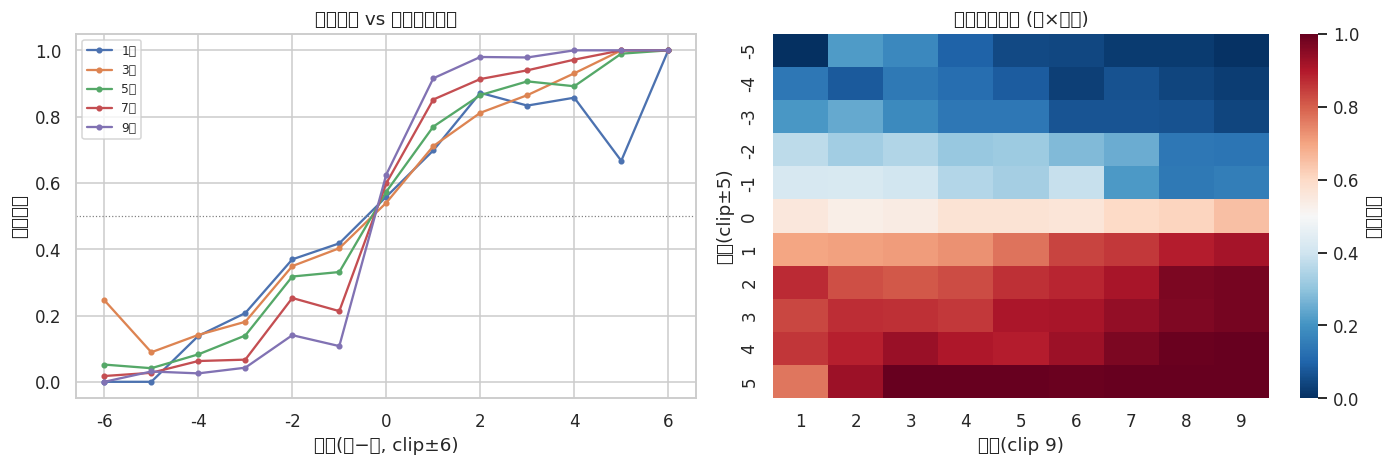

In [14]:
print("整體主隊勝率：%.3f（棒球通則約 0.54）" % pa["final_win"].mean())
print("各年主隊勝率：", pa.groupby("year")["final_win"].mean().round(3).to_dict())

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
for inn in [1, 3, 5, 7, 9]:
    d = pa[pa.inning == inn]
    grp = d.groupby(d.score_diff.clip(-6, 6))["final_win"].mean()
    ax[0].plot(grp.index, grp.values, "o-", ms=3, label=f"{inn}局")
ax[0].axhline(0.5, color="grey", lw=0.8, ls=":")
ax[0].set(xlabel="分差(主−客, clip±6)", ylabel="主隊勝率", title="經驗勝率 vs 分差（依局）"); ax[0].legend(fontsize=8)

piv = (pa.assign(sd=pa.score_diff.clip(-5, 5), inn=pa.inning.clip(1, 9))
       .pivot_table("final_win", "sd", "inn", aggfunc="mean"))
sns.heatmap(piv, ax=ax[1], cmap="RdBu_r", center=0.5, cbar_kws={"label": "主隊勝率"})
ax[1].set(xlabel="局數(clip 9)", ylabel="分差(clip±5)", title="主隊勝率熱圖 (局×分差)")
plt.tight_layout(); show_and_track(fig, "stage2_winrate.png"); plt.show()

**【目標 What?】** notched boxplot（比較中位數，**非**修剪）＋ 2023/2024 分布偏移檢查。
**【說明 How?】** notch=1.58·IQR/√n≈中位數 95% CI（McGill-Tukey-Larsen 1978）；比較各局分差、勝負兩組的 `WPA`，並比較兩季得分環境/勝率基底率。
**【解釋結果 Why?】** boxplot 用於**比較與目視抓錯**，不做 IQR 自動剔除；跨季差異視為協變量偏移。

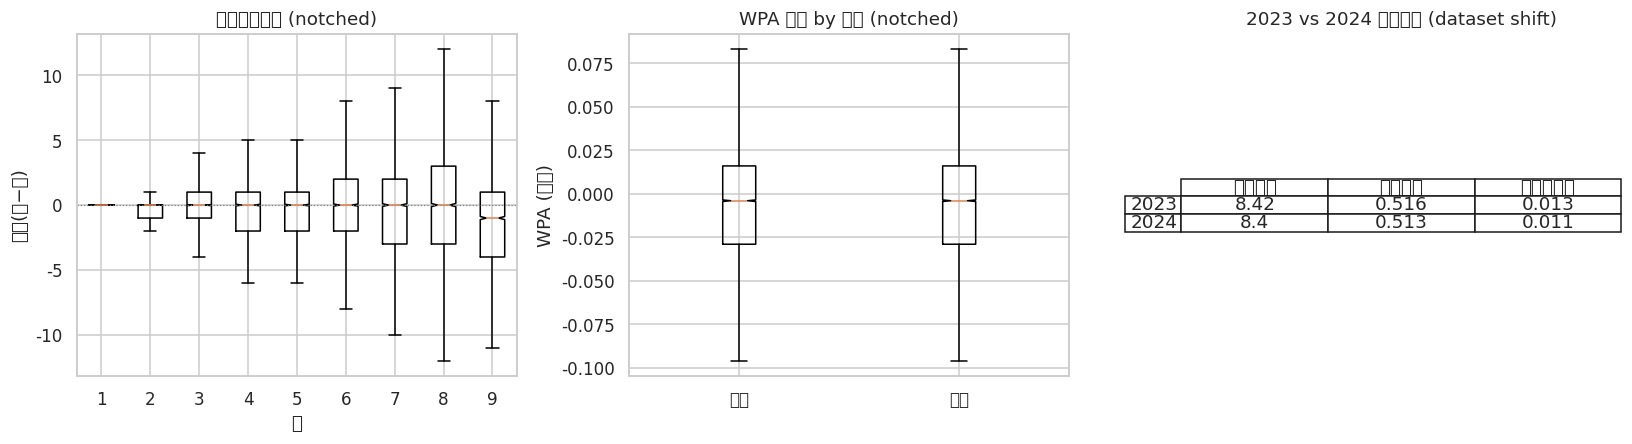

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
data = [pa.loc[pa.inning == i, "score_diff"].values for i in range(1, 10)]
ax[0].boxplot(data, notch=True, showfliers=False, tick_labels=[str(i) for i in range(1, 10)])
ax[0].axhline(0, color="grey", lw=0.8, ls=":")
ax[0].set(xlabel="局", ylabel="分差(主−客)", title="各局分差分布 (notched)")

wpa = pa.dropna(subset=["WPA"])
ax[1].boxplot([wpa.loc[wpa.final_win == 0, "WPA"], wpa.loc[wpa.final_win == 1, "WPA"]],
              notch=True, showfliers=False, tick_labels=["主敗", "主勝"])
ax[1].set(ylabel="WPA (官方)", title="WPA 分布 by 勝負 (notched)")

env = pa.groupby("year").agg(每場得分=("h_final", lambda s: round((pa.loc[s.index, "h_final"].groupby(pa.game_id).first()
      + pa.loc[s.index, "a_final"].groupby(pa.game_id).first()).mean(), 2)),
      主隊勝率=("final_win", "mean"), 延長賽比例=("is_extra_inning", "mean"))
env["主隊勝率"] = env["主隊勝率"].round(3); env["延長賽比例"] = env["延長賽比例"].round(3)
ax[2].axis("off"); ax[2].set_title("2023 vs 2024 分布偏移 (dataset shift)")
ax[2].table(cellText=env.values, colLabels=env.columns, rowLabels=env.index, loc="center", cellLoc="center")
plt.tight_layout(); show_and_track(fig, "stage2_boxplots.png"); plt.show()

## Stage 3 — 方法A：歷史頻率查表法（概念2-A）

**【目標 What?】** 用 train 的歷史頻率估各狀態主隊勝率（使用者例：500 中 150 勝 → 30%）。
**【說明 How?】** `LookupWP` 以 `(局,半,分差,出局,壘包)` 為鍵，階層收縮平滑；在 holdout 評估當 baseline。
**【解釋結果 Why?】** 這是吸收型 Markov 鏈的經驗估計、業界 WP 的原型；稀疏狀態自動 back-off。
**【後續觀察 Observations】** 示例「7局下/平手/1出/壘上無人」= 53 次 32 勝(0.604)、平滑後 0.617；查表 holdout Brier 0.183、AUC 0.803 → 合理 baseline。

In [16]:
tr, ho = make_split(pa)
Xtr, Xho = pa[tr], pa[ho]
ytr, yho = pa.final_win[tr].values, pa.final_win[ho].values
assert not (set(pa.game_id[tr]) & set(pa.game_id[ho])), "train/holdout 有同場洩漏！"
print(f"SPLIT_MODE={SPLIT_MODE}: train {tr.sum():,}列/{pa.game_id[tr].nunique()}場 | "
      f"holdout {ho.sum():,}列/{pa.game_id[ho].nunique()}場")

lookup = LookupWP().fit(Xtr, ytr)
# 使用者風格示例：某狀態的歷史勝/總數 → 勝率（ys 與 Xtr 同 index 對齊）
ys = pd.Series(ytr, index=Xtr.index)
ex_mask = (Xtr.inning == 7) & (Xtr.half_inning == 1) & (Xtr.score_diff == 0) & (Xtr.outs == 1) & (Xtr.base_state == 0)
ex = Xtr[ex_mask]
if len(ex):
    y_ex = ys[ex_mask]
    print(f"\n示例狀態(7局下/平手/1出局/壘上無人)：歷史 {int(y_ex.sum())} 勝 / {len(ex)} 次 = {y_ex.mean():.3f}"
          f"；查表(平滑後) {lookup.predict_proba(ex.head(1))[0, 1]:.3f}")
else:
    print("\n示例狀態樣本不足")
print("lookup holdout：", evaluate("lookup", yho, lookup.predict_proba(Xho)[:, 1]))

SPLIT_MODE=B: train 44,551列/581場 | holdout 5,399列/71場

示例狀態(7局下/平手/1出局/壘上無人)：歷史 32 勝 / 53 次 = 0.604；查表(平滑後) 0.617
lookup holdout： {'model': 'lookup', 'n': 5399, 'brier': 0.1828, 'logloss': 0.5617, 'auc': 0.8034}


## Stage 4 — 方法B：LightGBM + 邏輯迴歸（概念2-B / 步驟2）

**【目標 What?】** 訓練 LR / LGBM，比較**變體 A（Elo 當特徵）vs 變體 B（純情境）**。
**【說明 How?】** 同一切分；所有模型走 `FeatureModel` 統一介面、迴圈 fit/eval；機率經 isotonic 校準。**A、B 不疊用**（避免賽前先驗雙重計入）。
**【解釋結果 Why?】** LGBM 對分差單調、能抓交互作用；LR 可解釋對照；校準後機率可直接當勝率。
**【後續觀察 Observations】** `lgbm_B` 最佳（Brier 0.180、AUC 0.808），逼近職業 `homeWE` 對照(0.175)；變體 A(加 Elo) 未優於 B；Brier 依局 0.25→0.10（越打越確定）。

In [17]:
models = {"lookup": LookupWP()}
for tag, feats in [("B", FEAT_B), ("A", FEAT_A)]:
    models[f"lr_{tag}"] = FeatureModel(make_lr(feats), feats)
    models[f"lgbm_{tag}"] = FeatureModel(make_lgbm(feats), feats)
models["blend_B+Elo"] = WinProbBlender(make_lgbm(FEAT_B), FEAT_B)

pred = {}
for nm, m in models.items():                       # 一次定義、迴圈套用
    m.fit(Xtr, ytr)
    pred[nm] = m.predict_proba(Xho)[:, 1]
print("已訓練：", list(models))

已訓練： ['lookup', 'lr_B', 'lgbm_B', 'lr_A', 'lgbm_A', 'blend_B+Elo']


**【目標 What?】** holdout 評估表 + game-level bootstrap 95% CI + 職業對照線。
**【說明 How?】** 校準為頭號指標；每個 Brier 附以**場**為單位的 cluster bootstrap CI；對照官方 `homeWE`。
**【解釋結果 Why?】** 每場多列非 i.i.d.，naive CI 會過窄；對照線顯示我們離職業水準多近。

In [18]:
rows, gho = [], pa.game_id[ho].values
for nm, p in pred.items():
    r = evaluate(nm, yho, p)
    lo, hi = game_bootstrap_ci(yho, p, gho)
    r["brier_CI95"] = f"[{lo:.3f}, {hi:.3f}]"
    rows.append(r)
msk = Xho["homeWE"].notna().values
ref = evaluate("rebas_homeWE(職業對照)", yho[msk], Xho["homeWE"].clip(0, 1).values[msk]); ref["brier_CI95"] = "—"
rows.append(ref)
tbl = pd.DataFrame(rows)
show_and_track(tbl, "stage4_metrics.csv", "csv")
print(tbl.to_string(index=False))

             model    n  brier  logloss    auc     brier_CI95
            lookup 5399 0.1828   0.5617 0.8034 [0.148, 0.218]
              lr_B 5399 0.1828   0.5486 0.8020 [0.145, 0.219]
            lgbm_B 5399 0.1801   0.5336 0.8077 [0.146, 0.216]
              lr_A 5399 0.1869   0.5585 0.7980 [0.150, 0.225]
            lgbm_A 5399 0.1809   0.5505 0.8056 [0.144, 0.219]
       blend_B+Elo 5399 0.1841   0.5409 0.7954 [0.162, 0.208]
rebas_homeWE(職業對照) 5399 0.1751   0.5276 0.8136              —


**【目標 What?】** 校準曲線（多模型）＋ Brier 三分解＋分局表現。
**【說明 How?】** reliability diagram 疊各模型；Brier 分解成 reliability/resolution/uncertainty；Brier 依局分桶。
**【解釋結果 Why?】** 早局接近賽前(高不確定)、晚局趨近 0，呈現「越打越確定」。

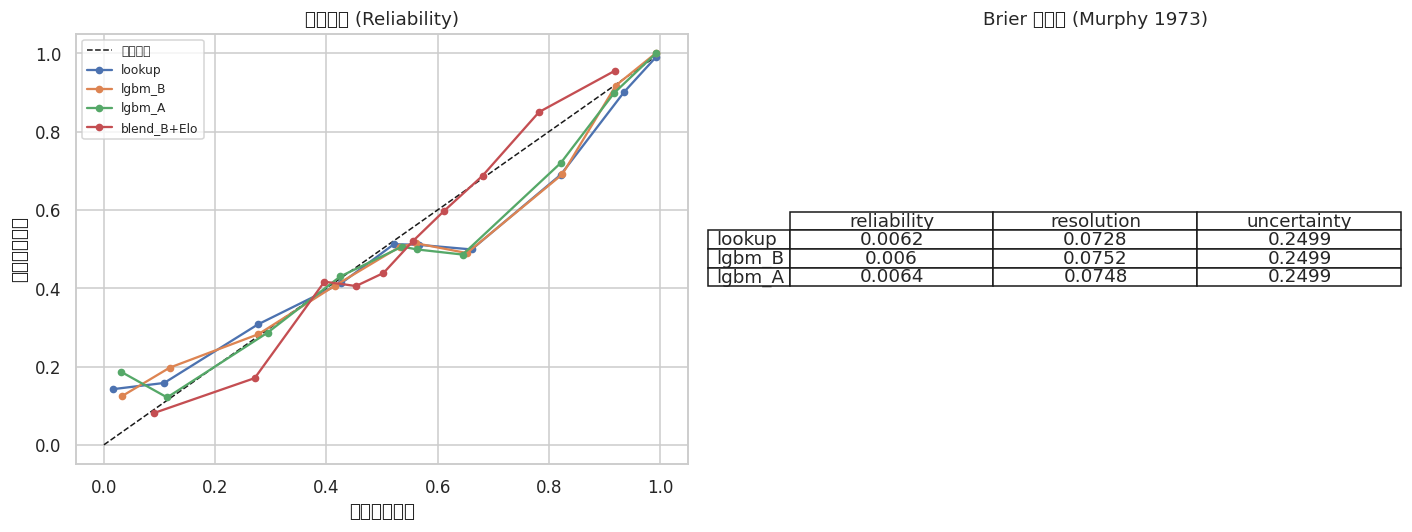

lgbm_A Brier 依局：
bucket
1-3局    0.2495
4-6局    0.1899
7-8局    0.0967
9局+     0.1145


In [19]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
plot_reliability({k: pred[k] for k in ["lookup", "lgbm_B", "lgbm_A", "blend_B+Elo"]}, yho, ax=ax[0])
dec = pd.DataFrame({k: brier_decomp(yho, pred[k]) for k in ["lookup", "lgbm_B", "lgbm_A"]}).T.round(4)
ax[1].axis("off"); ax[1].set_title("Brier 三分解 (Murphy 1973)")
ax[1].table(cellText=dec.values, colLabels=dec.columns, rowLabels=dec.index, loc="center", cellLoc="center")
plt.tight_layout(); show_and_track(fig, "stage4_calibration.png"); plt.show()

bk = pd.DataFrame({"inning": Xho.inning.values, "y": yho, "p": pred["lgbm_A"]})
bk["bucket"] = pd.cut(bk.inning, [0, 3, 6, 8, 99], labels=["1-3局", "4-6局", "7-8局", "9局+"])
print("lgbm_A Brier 依局：")
print(bk.groupby("bucket", observed=True).apply(lambda d: round(brier_score_loss(d.y, d.p), 4)).to_string())

**【目標 What?】** 特徵重要度與係數（可解釋性）。
**【說明 How?】** LGBM gain 重要度（變體 A）＋ LR 標準化係數（變體 A）。
**【解釋結果 Why?】** 確認分差/局數主導、賽前 Elo 於早局有貢獻。

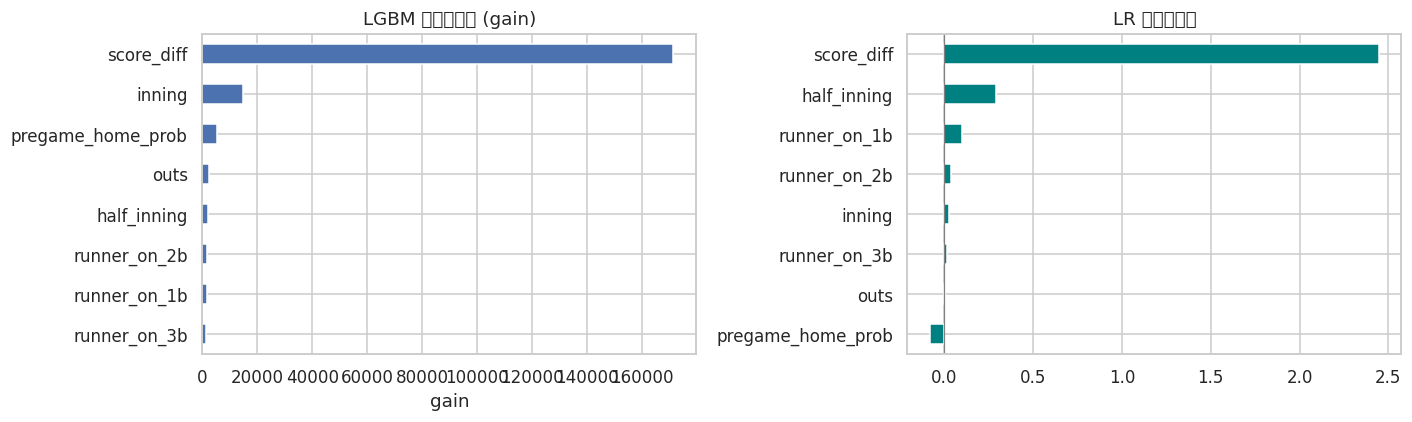

In [20]:
gb = models["lgbm_A"].est.calibrated_classifiers_[0].estimator
imp = pd.Series(gb.booster_.feature_importance("gain"), index=FEAT_A).sort_values()
lrest = models["lr_A"].est.calibrated_classifiers_[0].estimator
coef = pd.Series(lrest.named_steps["lr"].coef_[0],
                 index=[c for c in FEAT_A if c in CONT] + [c for c in FEAT_A if c not in CONT])
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
imp.plot.barh(ax=ax[0], title="LGBM 特徵重要度 (gain)"); ax[0].set_xlabel("gain")
coef.sort_values().plot.barh(ax=ax[1], color="teal", title="LR 標準化係數"); ax[1].axvline(0, color="grey", lw=0.8)
plt.tight_layout(); show_and_track(fig, "stage4_importance.png"); plt.show()

## Stage 5 — 賽前實力 + 貝氏動態融合（概念3 / 步驟3）

**【目標 What?】** 呈現 Elo 賽前實力，並把純情境輸出與賽前先驗融合。
**【說明 How?】** `Live = w(inning)·賽前 + (1−w)·賽中`；w 隨局數線性衰減（1局→1、9局→0）。台鋼為 2024 擴編新隊 → 冷啟動（初始 1500、前期評分不穩須標註）。
**【解釋結果 Why?】** 早局狀態資訊少、理論上靠賽前先驗較穩；但須用資料檢驗 CPBL 賽前訊號是否足以讓融合真的有幫助。
**【後續觀察 Observations】** 校準後 home 常數≈17（取代 50）；純 Elo 賽前 Brier 0.258 ≈ 無技巧基線 → CPBL 賽前訊號弱；貝氏融合(0.184) 未勝純情境(0.180)，即時勝率幾乎全靠場內狀態。

In [21]:
elo_tbl = pd.Series(elo.ratings_).sort_values(ascending=False).round(0)
print("season-end Elo 評分：\n", elo_tbl.to_string())
print("\n校準後 Elo home 常數=%.1f → 隱含主場優勢 %.3f（與 Stage 2 實測 %.3f 一致）"
      % (elo.home, 1 / (1 + 10 ** (-elo.home / 400)), pa["final_win"].mean()))

# 三條曲線比較 + 融合對早局校準的效果
blend_p = pred["blend_B+Elo"]
sit_p = pred["lgbm_B"]
pg_p = Xho["pregame_home_prob"].values
comp = []
for nm, p in [("純賽中 lgbm_B", sit_p), ("純賽前 Elo", pg_p), ("貝氏融合", blend_p)]:
    e13 = brier_score_loss(yho[Xho.inning <= 3], p[Xho.inning.values <= 3])
    comp.append(dict(模型=nm, Brier全場=round(brier_score_loss(yho, p), 4), Brier早局1_3=round(e13, 4)))
print("\n", pd.DataFrame(comp).to_string(index=False))

season-end Elo 評分：
 中信兄弟           1577.0
味全龍            1509.0
統一7-ELEVEn獅    1494.0
樂天桃猿           1492.0
台鋼雄鷹           1476.0
富邦悍將           1451.0

校準後 Elo home 常數=17.1 → 隱含主場優勢 0.525（與 Stage 2 實測 0.514 一致）

         模型  Brier全場  Brier早局1_3
純賽中 lgbm_B   0.1801      0.2488
   純賽前 Elo   0.2583      0.2567
      貝氏融合   0.1841      0.2495


## Stage 6 — 即時推論函數 + 動態勝率曲線（概念4 / 步驟3–5）

**【目標 What?】** 提供 `predict_live_probability()` 並驗證關鍵情境方向正確。
**【說明 How?】** 用 train 訓練 demo 模型；測使用者範例（9局下、平手、2出局、滿壘、賽前55%）與數個標準狀態。
**【解釋結果 Why?】** 方向性須正確：領先→高、落後→低、平手近賽前。下半局滿壘主隊為 favored，但**2 出局**時再見轉換不確定（對比同狀態 0 出局≈99%），反映 CPBL 晚局高槓桿樣本稀疏、結果適度而非極端。
**【後續觀察 Observations】** 使用者範例 9下/平手/2出/滿壘→主隊 53.7%（favored；0 出局滿壘達 99%）；領先+3→0.96、落後−3→0.05，方向性全部正確。

In [22]:
demo = FeatureModel(make_lgbm(FEAT_A), FEAT_A).fit(Xtr, ytr)
h, a = predict_live_probability(demo, 9, 1, 0, 2, 1, 1, 1, 0.55)
print(f"★ 使用者範例 9局下/平手/2出局/滿壘/賽前55% → 主隊 {h:.1%} 客隊 {a:.1%}")
canon = [("9下 平手 2出 滿壘", 9, 1, 0, 2, 1, 1, 1), ("9下 平手 0出 滿壘", 9, 1, 0, 0, 1, 1, 1),
         ("9下 主+3 0出 無人", 9, 1, 3, 0, 0, 0, 0), ("9下 主−3 2出 無人", 9, 1, -3, 2, 0, 0, 0),
         ("1上 平手 0出 無人", 1, 0, 0, 0, 0, 0, 0)]
print("\n方向性檢查 (賽前=0.55)：")
for nm, *args in canon:
    print(f"  {nm}: 主隊勝率 {predict_live_probability(demo, *args, 0.55)[0]:.3f}")

★ 使用者範例 9局下/平手/2出局/滿壘/賽前55% → 主隊 53.7% 客隊 46.3%

方向性檢查 (賽前=0.55)：
  9下 平手 2出 滿壘: 主隊勝率 0.537
  9下 平手 0出 滿壘: 主隊勝率 0.991
  9下 主+3 0出 無人: 主隊勝率 0.963
  9下 主−3 2出 無人: 主隊勝率 0.045
  1上 平手 0出 無人: 主隊勝率 0.531


**【目標 What?】** 動態勝率曲線：點選任一場、用該場之前資料訓練 (expanding) 並回放。
**【說明 How?】** `predict_game_live(gid, policy)`：`expanding`=用 `date<該場` 全部資料 refit（gold standard、零洩漏）；`fixed`=用已訓練模型。挑 holdout 中分差正負交替最多的戲劇性比賽，疊官方 `homeWE`。
**【解釋結果 Why?】** 逐打席累積即步驟4 pipeline 的離線等價；曲線在再見致勝分當下收斂到 1。
**【後續觀察 Observations】** 自動挑出 2 場分差多次易主的戲劇比賽（變號 8、7 次）；expanding 曲線與官方 `homeWE` 走勢吻合、終局收斂到 100%/0%。

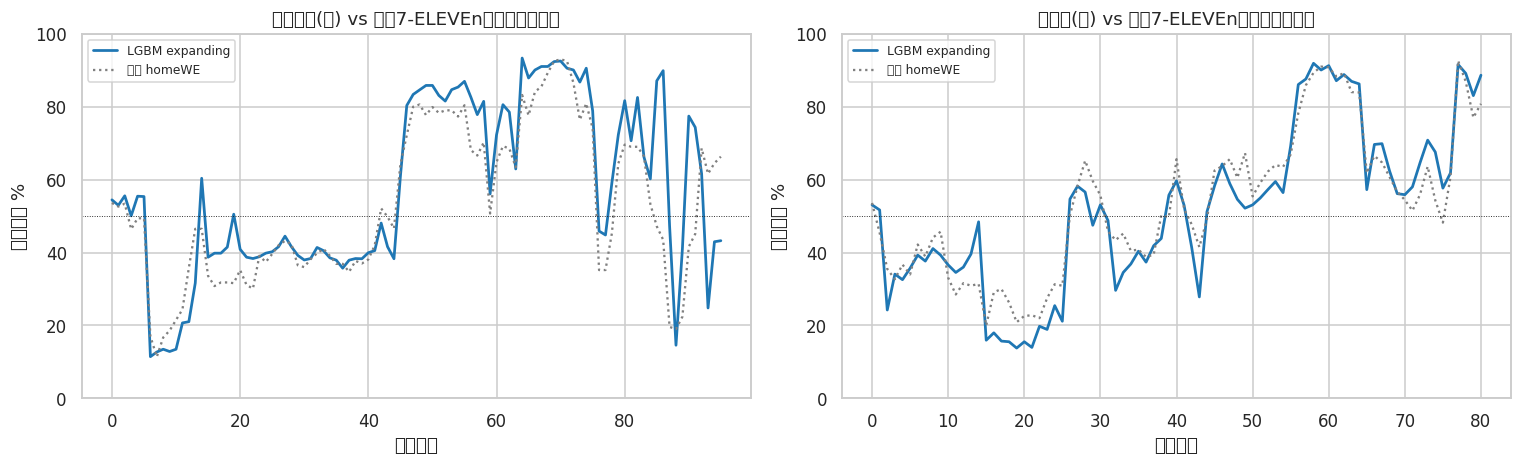

挑選比賽（分差變號次數）： {'CPBL-2024-xa#308': 8, 'CPBL-2024-xa#300': 7}


In [23]:
def predict_game_live(gid, policy="expanding"):
    gdf = pa[pa.game_id == gid]
    if policy == "expanding":
        trn = pa[pa.date < gdf.date.iloc[0]]
        if trn.game_id.nunique() < 30:
            return None                          # 太早期、歷史不足
        mdl = FeatureModel(make_lgbm(FEAT_A), FEAT_A).fit(trn, trn.final_win.values)
    else:
        mdl = demo
    return game_curve(mdl, gdf)

# 挑 2 場最戲劇（分差正負號變換最多）的 holdout 比賽
swings = (pa[ho].groupby("game_id")
          .apply(lambda d: int((np.sign(d.sort_values(["inning", "half_inning", "pa_idx"]).score_diff)
                                .diff().fillna(0) != 0).sum()))
          .sort_values(ascending=False))
picks = swings.index[:2].tolist()

fig, axes = plt.subplots(1, len(picks), figsize=(7 * len(picks), 4.4), squeeze=False)
for axc, gid in zip(axes[0], picks):
    g, wp = predict_game_live(gid, "expanding")
    axc.plot(range(len(wp)), wp * 100, "-", color="tab:blue", lw=1.8, label="LGBM expanding")
    if g["homeWE"].notna().any():
        axc.plot(range(len(g)), g["homeWE"].clip(0, 1).values * 100, ":", color="grey", label="官方 homeWE")
    axc.axhline(50, color="k", lw=0.6, ls=":")
    res = "主勝" if g.final_win.iloc[0] else "客勝"
    axc.set(ylim=(0, 100), xlabel="打席進程", ylabel="主隊勝率 %",
            title=f"{g.home_team.iloc[0]}(主) vs {g.away_team.iloc[0]}　結果：{res}")
    axc.legend(fontsize=8)
plt.tight_layout(); show_and_track(fig, "stage6_winprob_curve.png"); plt.show()
print("挑選比賽（分差變號次數）：", {k: int(swings[k]) for k in picks})

## Stage 7 — 綜合與延伸

**【目標 What?】** 模型總比較、誠實侷限與未來工作。
**【說明 How?】** 彙整各模型 Brier/log-loss/AUC；說明延長賽特徵定義與後續方向。
**【解釋結果 Why?】** 收斂全篇結論，標示資料/方法邊界。

In [24]:
summary = pd.DataFrame(rows)[["model", "n", "brier", "logloss", "auc", "brier_CI95"]]
show_and_track(summary, "stage7_summary.csv", "csv")
print("模型總比較（holdout，SPLIT_MODE=%s）：" % SPLIT_MODE)
print(summary.to_string(index=False))

模型總比較（holdout，SPLIT_MODE=B）：
             model    n  brier  logloss    auc     brier_CI95
            lookup 5399 0.1828   0.5617 0.8034 [0.148, 0.218]
              lr_B 5399 0.1828   0.5486 0.8020 [0.145, 0.219]
            lgbm_B 5399 0.1801   0.5336 0.8077 [0.146, 0.216]
              lr_A 5399 0.1869   0.5585 0.7980 [0.150, 0.225]
            lgbm_A 5399 0.1809   0.5505 0.8056 [0.144, 0.219]
       blend_B+Elo 5399 0.1841   0.5409 0.7954 [0.162, 0.208]
rebas_homeWE(職業對照) 5399 0.1751   0.5276 0.8136              —


### 結論與侷限
- **方法**：查表法（Markov 經驗估計）給可解釋 baseline；LightGBM 校準後最接近職業 `homeWE` 對照線（Brier 0.180 vs 0.175）；**加賽前 Elo（變體 A）與貝氏融合均未勝純情境（變體 B）**——CPBL 賽前訊號弱（主場優勢僅 ~0.51、球隊接近），故即時勝率**幾乎全由場內 per-PA 狀態決定**（這本身是有意義的發現）。
- **侷限**：每場約 70+ 列標籤相關 → 已用 game-level cluster bootstrap CI；CPBL 樣本量有限、跨季有規則/陣容偏移（2024 突破僵局制、台鋼擴編）；無 live API → 以 replay 等價模擬。
- **延長賽 (額外局數) 特徵**：`inning` 保持數值、查表封頂「9+」、融合權重 `w=0`（純靠賽中）。
- **未來**：投手當日球速、打者對戰歷史、bullpen 狀態等 per-PA 連續特徵（資料已含 `events.velocity`，可延伸）。

## Stage 8 — 輸出開關

**【目標 What?】** 列出產物；`DOWNLOAD_ALL=True` 時打包下載。
**【說明 How?】** 預設 inline-only；切 True 後把 ARTIFACTS 打包成 zip + FileLink。
**【解釋結果 Why?】** 預設不寫檔、保持 notebook 乾淨可重現。

In [25]:
print("ARTIFACTS：")
for nm, kind in ARTIFACTS:
    print(f"  [{kind}] {nm}")
if DOWNLOAD_ALL:
    zp = "/tmp/cpbl_live_winprob_artifacts.zip"
    with zipfile.ZipFile(zp, "w") as z:
        for nm, _ in ARTIFACTS:
            p = Path(f"/tmp/{nm}")
            if p.exists(): z.write(p, nm)
    from IPython.display import FileLink, display
    print("已打包：", zp); display(FileLink(zp))
else:
    print("\nDOWNLOAD_ALL=False → 僅 inline 顯示，未寫檔。")

ARTIFACTS：
  [fig] stage2_winrate.png
  [fig] stage2_boxplots.png
  [csv] stage4_metrics.csv
  [fig] stage4_calibration.png
  [fig] stage4_importance.png
  [fig] stage6_winprob_curve.png
  [csv] stage7_summary.csv

DOWNLOAD_ALL=False → 僅 inline 顯示，未寫檔。
